<a href="https://colab.research.google.com/github/SoyOrnella/telecomx1/blob/main/TelecomX_LATAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#📌 Extracción

In [2]:
import pandas as pd

try:
    # Carga el archivo JSON localmente
    df = pd.read_json('/content/TelecomX_Data.json')
    print("Datos cargados con éxito desde TelecomX_Data.json:")
    print(df.head())

except FileNotFoundError:
    print("Error: El archivo 'TelecomX_Data.json' no se encontró. Asegúrate de que esté en el directorio '/content/'.")
except pd.errors.EmptyDataError:
    print("Error: El archivo 'TelecomX_Data.json' está vacío.")
except Exception as e:
    print(f"Ha ocurrido un error inesperado al cargar el archivo JSON: {e}")


Datos cargados con éxito desde TelecomX_Data.json:
   customerID Churn                                           customer  \
0  0002-ORFBO    No  {'gender': 'Female', 'SeniorCitizen': 0, 'Part...   
1  0003-MKNFE    No  {'gender': 'Male', 'SeniorCitizen': 0, 'Partne...   
2  0004-TLHLJ   Yes  {'gender': 'Male', 'SeniorCitizen': 0, 'Partne...   
3  0011-IGKFF   Yes  {'gender': 'Male', 'SeniorCitizen': 1, 'Partne...   
4  0013-EXCHZ   Yes  {'gender': 'Female', 'SeniorCitizen': 1, 'Part...   

                                             phone  \
0   {'PhoneService': 'Yes', 'MultipleLines': 'No'}   
1  {'PhoneService': 'Yes', 'MultipleLines': 'Yes'}   
2   {'PhoneService': 'Yes', 'MultipleLines': 'No'}   
3   {'PhoneService': 'Yes', 'MultipleLines': 'No'}   
4   {'PhoneService': 'Yes', 'MultipleLines': 'No'}   

                                            internet  \
0  {'InternetService': 'DSL', 'OnlineSecurity': '...   
1  {'InternetService': 'DSL', 'OnlineSecurity': '...   
2  {'Intern

#🔧 Transformación

In [3]:
# Función para aplanar columnas anidadas
def flatten_json_column(df, column_name):
    # Convierte la columna de diccionarios en un DataFrame
    flattened_df = pd.json_normalize(df[column_name])
    # Renombra las columnas aplanadas para evitar conflictos y claridad
    flattened_df.columns = [f"{column_name}_{subcol}" for subcol in flattened_df.columns]
    # Elimina la columna original anidada y concatena las nuevas columnas
    df = pd.concat([df.drop(columns=[column_name]), flattened_df], axis=1)
    return df

# Lista de columnas a aplanar
columns_to_flatten = ['customer', 'phone', 'internet', 'account']

# Aplana cada columna en la lista
for col in columns_to_flatten:
    df = flatten_json_column(df, col)

print("DataFrame después de aplanar las columnas anidadas:")
print(df.head())

# Verificar las columnas resultantes
print("\nNuevas columnas del DataFrame:")
print(df.columns.tolist())


DataFrame después de aplanar las columnas anidadas:
   customerID Churn customer_gender  customer_SeniorCitizen customer_Partner  \
0  0002-ORFBO    No          Female                       0              Yes   
1  0003-MKNFE    No            Male                       0               No   
2  0004-TLHLJ   Yes            Male                       0               No   
3  0011-IGKFF   Yes            Male                       1              Yes   
4  0013-EXCHZ   Yes          Female                       1              Yes   

  customer_Dependents  customer_tenure phone_PhoneService phone_MultipleLines  \
0                 Yes                9                Yes                  No   
1                  No                9                Yes                 Yes   
2                  No                4                Yes                  No   
3                  No               13                Yes                  No   
4                  No                3                Yes     

#📊 Carga y análisis

In [7]:
print("Información general del DataFrame:")
df.info()

print("\nTipos de datos de cada columna:")
print(df.dtypes)

# Identificar y convertir 'account_Charges.Total' a numérico
# Primero, veamos los valores únicos en 'account_Charges.Total' que no son numéricos.
# Estos suelen ser espacios en blanco o cadenas como ' '.
# Luego, los convertimos a NaN y finalmente a float.

# Reemplazar valores no numéricos (como espacios en blanco) con NaN y luego convertir a float
df['account_Charges.Total'] = pd.to_numeric(df['account_Charges.Total'], errors='coerce')

# Llenar los valores NaN resultantes (que podrían ser de los espacios en blanco originales)
# con 0, asumiendo que un valor total no registrado significa 0 cargos.
df['account_Charges.Total'] = df['account_Charges.Total'].fillna(0)

# Eliminar filas donde 'Churn' es una cadena vacía
initial_rows = df.shape[0]
df = df[df['Churn'] != ''].copy()
print(f"\nSe eliminaron {initial_rows - df.shape[0]} filas con valores vacíos en la columna 'Churn'.")

print("\nValores nulos por columna (después de la conversión de TotalCharges y limpieza de Churn):")
print(df.isnull().sum())

print("\nTipos de datos de cada columna (después de la conversión de TotalCharges y limpieza de Churn):")
print(df.dtypes)

print("\nNúmero de valores únicos por columna (primeras 50 columnas si hay muchas):")
print(df.nunique().head(50))


Información general del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer_gender            7267 non-null   object 
 3   customer_SeniorCitizen     7267 non-null   int64  
 4   customer_Partner           7267 non-null   object 
 5   customer_Dependents        7267 non-null   object 
 6   customer_tenure            7267 non-null   int64  
 7   phone_PhoneService         7267 non-null   object 
 8   phone_MultipleLines        7267 non-null   object 
 9   internet_InternetService   7267 non-null   object 
 10  internet_OnlineSecurity    7267 non-null   object 
 11  internet_OnlineBackup      7267 non-null   object 
 12  internet_DeviceProtection  7267 non-null   object 
 13  internet_Tech

#📄Informe final


Análisis de la columna 'Churn':
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Porcentaje de Churn:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


/tmp/ipykernel_1196/1267577567.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette='viridis')


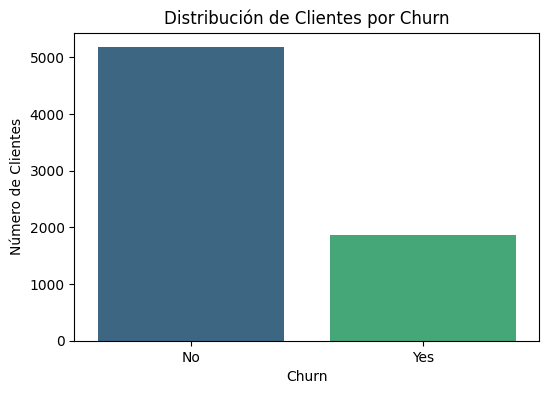


Estadísticas de account_Charges.Monthly y account_Charges.Total por Churn:
       account_Charges.Monthly  account_Charges.Total
Churn                                                
No                   61.265124            2549.911442
Yes                  74.441332            1531.796094


/tmp/ipykernel_1196/1267577567.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='account_Charges.Monthly', data=df, palette='plasma')
/tmp/ipykernel_1196/1267577567.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='account_Charges.Total', data=df, palette='plasma')


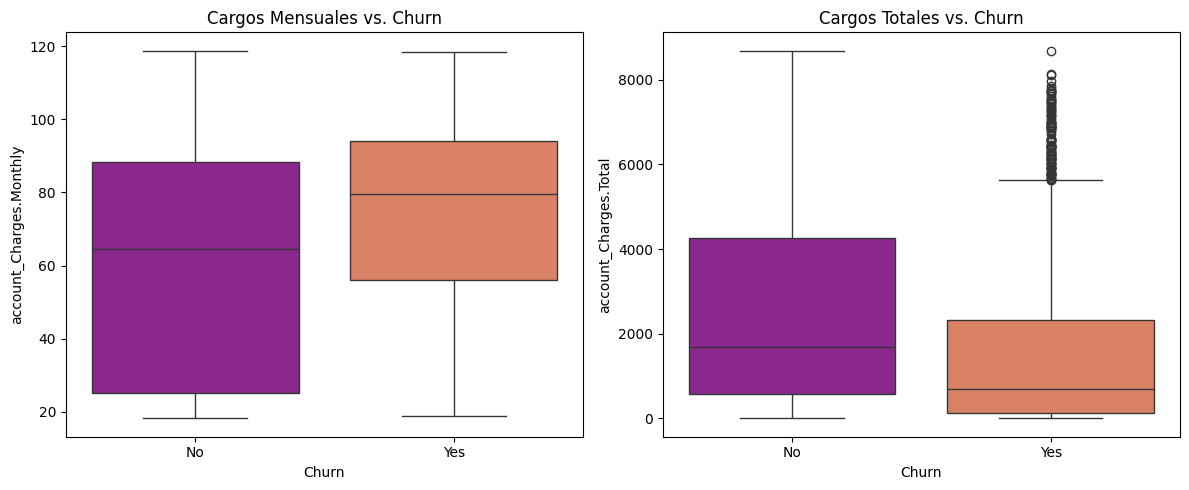

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Análisis de la columna 'Churn'
print("\nAnálisis de la columna 'Churn':")
print(df['Churn'].value_counts())
print("\nPorcentaje de Churn:")
print(df['Churn'].value_counts(normalize=True) * 100)

# Visualización de la distribución de Churn
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df, palette='viridis')
plt.title('Distribución de Clientes por Churn')
plt.xlabel('Churn')
plt.ylabel('Número de Clientes')
plt.show()

# Ahora que 'account_Charges.Total' es numérico, podemos analizarlo con Churn
print("\nEstadísticas de account_Charges.Monthly y account_Charges.Total por Churn:")
print(df.groupby('Churn')[['account_Charges.Monthly', 'account_Charges.Total']].mean())

# Visualización de la relación entre Charges y Churn
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(x='Churn', y='account_Charges.Monthly', data=df, palette='plasma')
plt.title('Cargos Mensuales vs. Churn')

plt.subplot(1, 2, 2)
sns.boxplot(x='Churn', y='account_Charges.Total', data=df, palette='plasma')
plt.title('Cargos Totales vs. Churn')
plt.tight_layout()
plt.show()
